## Marketing Insight for E-Commerce Company Machine Learning - Vivek Kumar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

## Import all The libraires which are important for solving the problem.

## Import the Datasets

In [2]:
cust =pd.read_excel('CustomersData.xlsx')
dist =pd.read_csv('Discount_Coupon.csv')
market =pd.read_csv('Marketing_Spend.csv',parse_dates=['Date'])
sales =pd.read_csv('Online_Sales.csv',parse_dates=['Transaction_Date'])
tax =pd.read_excel('Tax_amount.xlsx')

In [3]:
dist =pd.read_csv('Discount_Coupon.csv')

## Standaize the column names

In [4]:
sales.columns = sales.columns.str.strip().str.lower()
market.columns = market.columns.str.strip().str.lower()
tax.columns = tax.columns.str.strip().str.lower()
dist.columns = dist.columns.str.strip().str.lower()
cust.columns = cust.columns.str.strip().str.lower()

## Basic Data Cleaning

In [5]:
## Remove Duplicates.
sales.drop_duplicates(inplace=True)
cust.drop_duplicates(inplace=True)
market.drop_duplicates(inplace=True)
tax.drop_duplicates(inplace=True)
dist.drop_duplicates(inplace=True)

In [6]:
market

,date,offline_spend,online_spend
0,2019-01-01,4500,2424.50
1,2019-01-02,4500,3480.36
2,2019-01-03,4500,1576.38
3,2019-01-04,4500,2928.55
4,2019-01-05,4500,4055.30
...,...,...,...
360,2019-12-27,4000,3396.87
361,2019-12-28,4000,3246.84
362,2019-12-29,4000,2546.58
363,2019-12-30,4000,674.31


## Create Date Features.

In [7]:
sales['year'] = sales['transaction_date'].dt.year
sales['month'] = sales['transaction_date'].dt.month
sales['day'] = sales['transaction_date'].dt.day
sales['week'] = sales['transaction_date'].dt.isocalendar().week
sales['weekday'] = sales['transaction_date'].dt.day_name()

## Prepare the Discount Mapping

In [8]:
# convert string month to numeric if required


In [9]:
dist['month'] = pd.to_datetime(dist['month'], errors='coerce').dt.month
dist.month.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

## Creating mapping(Month + category = Discount%)

In [10]:
dist_map = dist.set_index(['month','product_category'])['discount_pct'].to_dict()

In [11]:
## Asign discount to each sales row:
def map_discount(row):
    return dist_map.get((row['month'],row['product_category']),0)

In [13]:
sales['discount_pct'] = sales.apply(map_discount,axis = 1)/100

## Prepare GST Mapping

In [14]:
gst_map = tax.set_index('product_category')['gst'].to_dict()


In [15]:
sales['gst'] = sales['product_category'].map(gst_map).fillna(0)

## Compute the invoice values

In [16]:
sales['base_amount'] = sales['quantity']*sales['avg_price']
sales['after_discount'] = sales['base_amount']*(1-sales['discount_pct'])
sales['after_tax'] = sales['after_discount']*(1+sales['gst'])
sales['invoice_value'] = sales['after_tax'] + sales['delivery_charges']

## Clean customer_data

In [17]:
cust['gender'] = cust['gender'].str.title()

In [18]:
cust.head(5)

,customerid,gender,location,tenure_months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


In [19]:
cust['location'] = cust['location'].str.title().str.strip()

## Merge Sales + customer_data

In [20]:
datas = cust.merge(sales,on = 'customerid',how = 'right')

In [21]:
datas.head()

,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,month,day,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,1,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,1,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,1,1,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,1,1,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,1,1,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230


In [22]:
data = datas.merge(market.rename(columns={'date':'transaction_date'}),
                  on = 'transaction_date',
                  how = 'left'
                  )

## Final Checks

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customerid           52924 non-null  int64         
 1   gender               52924 non-null  str           
 2   location             52924 non-null  str           
 3   tenure_months        52924 non-null  int64         
 4   transaction_id       52924 non-null  int64         
 5   transaction_date     52924 non-null  datetime64[us]
 6   product_sku          52924 non-null  str           
 7   product_description  52924 non-null  str           
 8   product_category     52924 non-null  str           
 9   quantity             52924 non-null  int64         
 10  avg_price            52924 non-null  float64       
 11  delivery_charges     52924 non-null  float64       
 12  coupon_status        52924 non-null  str           
 13  year                 52924 non-null  int32

In [24]:
data.isnull().sum()

customerid             0
gender                 0
location               0
tenure_months          0
transaction_id         0
transaction_date       0
product_sku            0
product_description    0
product_category       0
quantity               0
avg_price              0
delivery_charges       0
coupon_status          0
year                   0
month                  0
day                    0
week                   0
weekday                0
discount_pct           0
gst                    0
base_amount            0
after_discount         0
after_tax              0
invoice_value          0
offline_spend          0
online_spend           0
dtype: int64

In [25]:
data.to_csv('Cleaned_transaction_data.csv',index=False)

## Exploratory Data Analysis (EDA)

In [26]:
# Notebook settings
plt.style.use('ggplot')
sns.set(rc={'figure.figsize':(12,6)})

# Load cleaned dataset
df = pd.read_csv("Cleaned_Transaction_Data.csv", parse_dates=['transaction_date'])

In [27]:
df.head()

,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295,4500,2424.5
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843,4500,2424.5
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230,4500,2424.5


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customerid           52924 non-null  int64         
 1   gender               52924 non-null  str           
 2   location             52924 non-null  str           
 3   tenure_months        52924 non-null  int64         
 4   transaction_id       52924 non-null  int64         
 5   transaction_date     52924 non-null  datetime64[us]
 6   product_sku          52924 non-null  str           
 7   product_description  52924 non-null  str           
 8   product_category     52924 non-null  str           
 9   quantity             52924 non-null  int64         
 10  avg_price            52924 non-null  float64       
 11  delivery_charges     52924 non-null  float64       
 12  coupon_status        52924 non-null  str           
 13  year                 52924 non-null  int64

## Monthly Revenue Trend

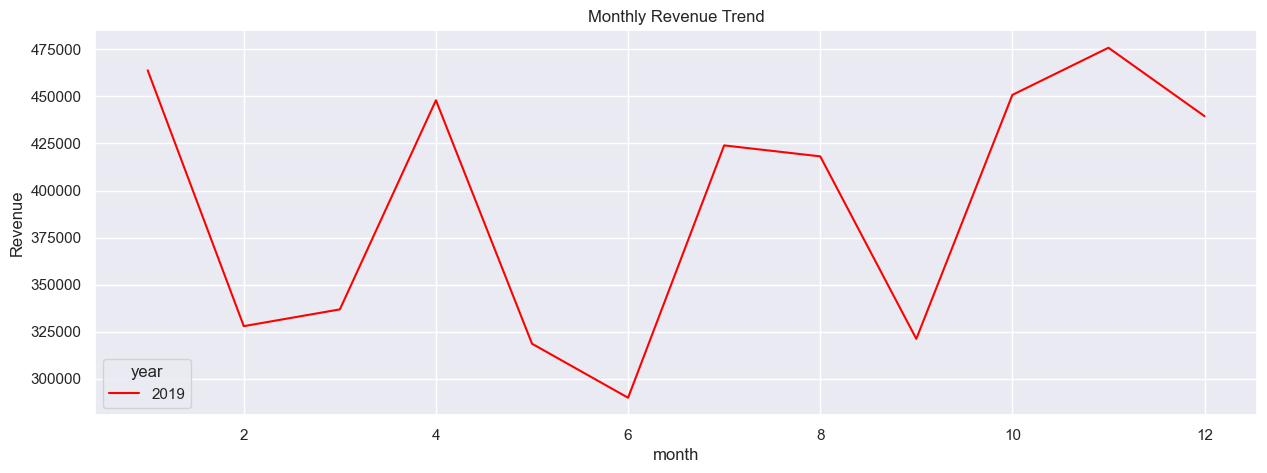

In [29]:
monthly_reve = df.groupby(['year','month'])['invoice_value'].sum().reset_index(name = 'monthly_revenue')

plt.figure(figsize=(15,5))
sns.lineplot(data = monthly_reve,x = 'month',y = 'monthly_revenue',palette=['red', 'blue', 'green', 'black'],markers=True,hue='year')
plt.title('Monthly Revenue Trend')
plt.ylabel('Months')
plt.ylabel('Revenue')
plt.show()

## Monthly Order Trend

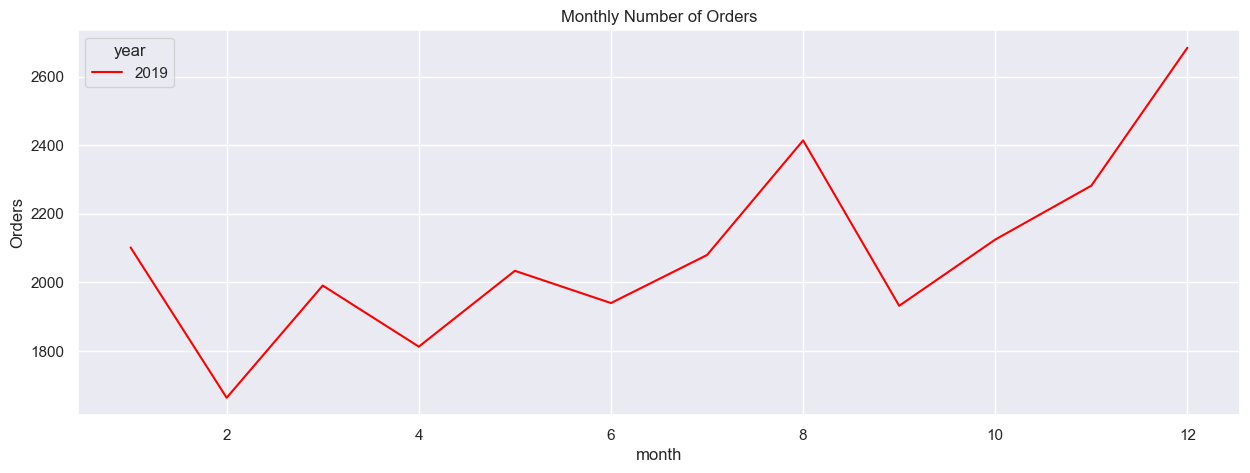

In [30]:
monthly_order = df.groupby(['year','month'])['transaction_id'].nunique().reset_index(name = 'total_monthly_customer')

plt.figure(figsize=(15,5))
sns.lineplot(data = monthly_order,x = 'month',y = 'total_monthly_customer',hue = 'year',palette=['red', 'blue', 'green', 'black'],markers=True)
plt.title('Monthly Number of Orders')
plt.ylabel('Orders')
plt.show()

## Average Order Value(AOV)

In [31]:
df['aov'] = df.groupby('transaction_id')['invoice_value'].transform('sum')

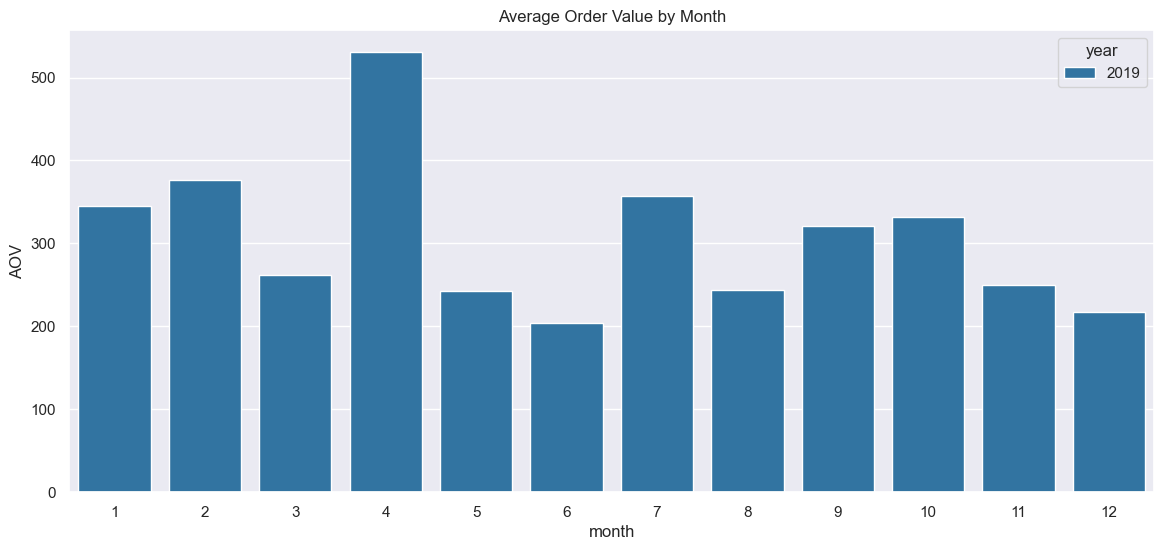

In [32]:
aov_month = df.groupby(['year','month'])['aov'].mean().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data = aov_month, x = 'month',y = 'aov',hue = 'year',palette='tab10')
plt.title("Average Order Value by Month")
plt.ylabel("AOV")
plt.show()

## New vs Returning Customers (Monthly)

In [33]:
## Identity first purchase month
first_purchase = df.groupby('customerid')['transaction_date'].min().reset_index()

In [34]:
first_purchase['fp_year'] = first_purchase['transaction_date'].dt.year
first_purchase['fp_month'] = first_purchase['transaction_date'].dt.month

In [35]:
first_purchase

,customerid,transaction_date,fp_year,fp_month
0,12346,2019-09-15,2019,9
1,12347,2019-03-24,2019,3
2,12348,2019-06-22,2019,6
3,12350,2019-12-14,2019,12
4,12356,2019-09-15,2019,9
...,...,...,...,...
1463,18259,2019-04-05,2019,4
1464,18260,2019-06-22,2019,6
1465,18269,2019-04-05,2019,4
1466,18277,2019-10-23,2019,10


In [36]:
dfs =  df.merge(first_purchase[['customerid','fp_year','fp_month']], on='customerid', how='left')

In [37]:
## Tag new vs existing customers 
dfs['customer_type'] = np.where(
    (dfs['year']==dfs['fp_year']) & (dfs['month']==dfs['fp_month']), 
    'New', 
    'Returning'
)

In [38]:
## Monthly Revenue Split
cust_rev = dfs.groupby(['year','month','customer_type'])['invoice_value'].sum().reset_index(name = 'tot_revenue')

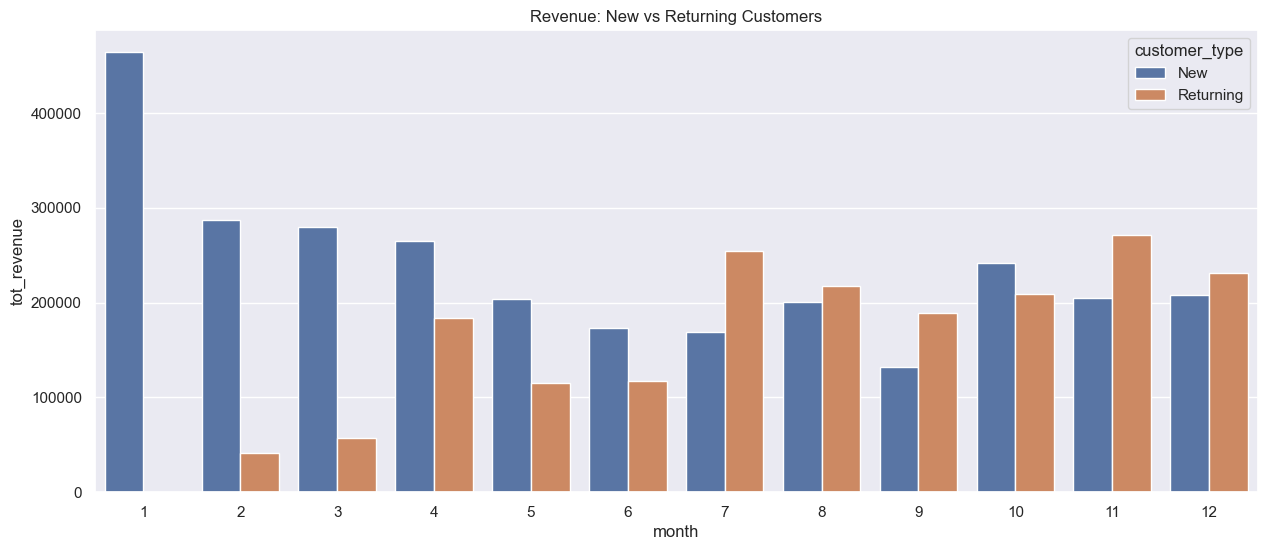

In [39]:
plt.figure(figsize=(15,6))
sns.barplot(data=cust_rev, x='month', y='tot_revenue', hue='customer_type')
plt.title("Revenue: New vs Returning Customers")
plt.show()

## Customer Acquisition per Month

In [40]:
acquition = dfs[dfs['customer_type']=='New'].groupby(['year','month'])['customerid'].nunique().reset_index(name = 'acquition_cust')

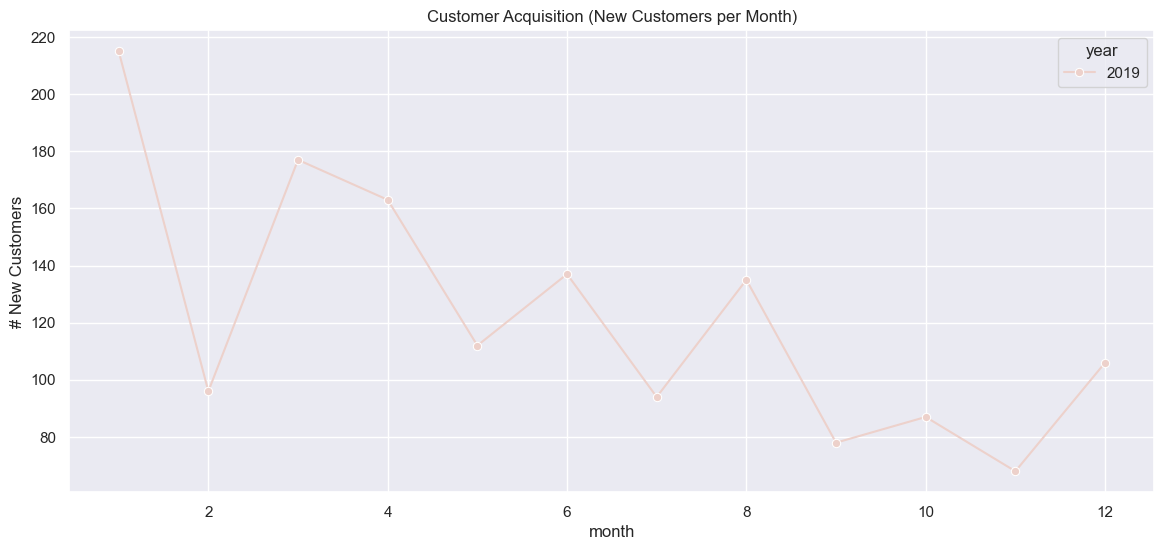

In [41]:
plt.figure(figsize=(14,6))
sns.lineplot(data=acquition, x='month', y='acquition_cust', hue='year', marker='o')
plt.title("Customer Acquisition (New Customers per Month)")
plt.ylabel("# New Customers")
plt.show()

## Customer Retention Month-over-Month

In [42]:
monthly_customers = dfs.groupby(['year','month'])['customerid'].unique()

retention = {}
months = list(monthly_customers.index)

for i in range(1, len(months)):
    prev = set(monthly_customers.iloc[i-1])
    curr = set(monthly_customers.iloc[i])
    retention_rate = len(curr.intersection(prev)) / len(prev) * 100
    retention[months[i]] = retention_rate


In [43]:
retention_df = pd.DataFrame({
    'period': retention.keys(),
    'retention_rate': retention.values()
})

In [44]:
retention_df['period_str'] = retention_df['period'].apply(lambda x: f"{x[0]}-{x[1]:02d}")

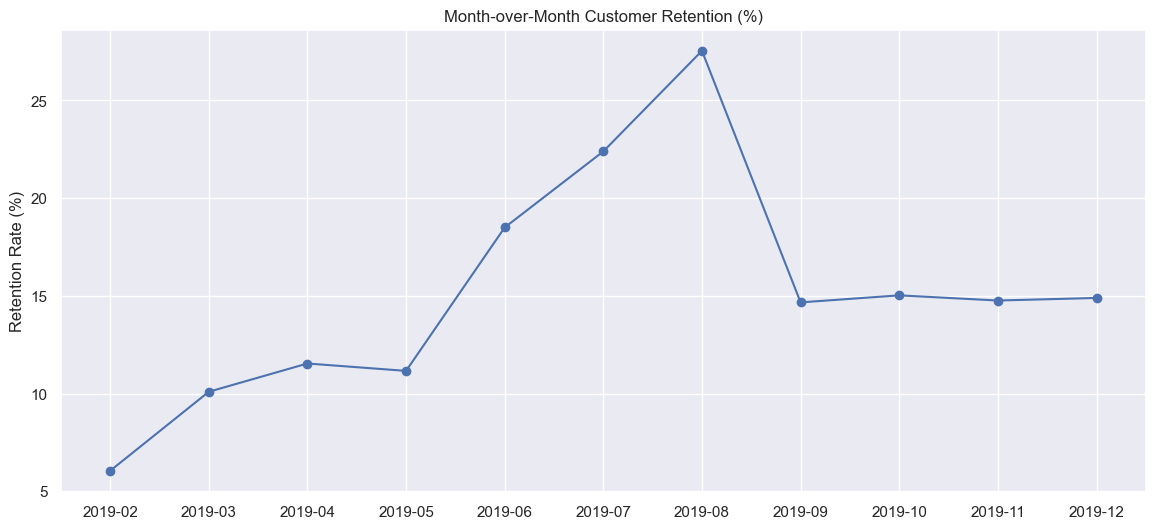

In [45]:
plt.figure(figsize=(14,6))
plt.plot(retention_df['period_str'], retention_df['retention_rate'], marker='o')
plt.title("Month-over-Month Customer Retention (%)")
plt.ylabel("Retention Rate (%)")
plt.show()

## Category-wise Revenue

In [46]:
cat_rev = dfs.groupby('product_category')['invoice_value'].sum().sort_values(ascending=False)

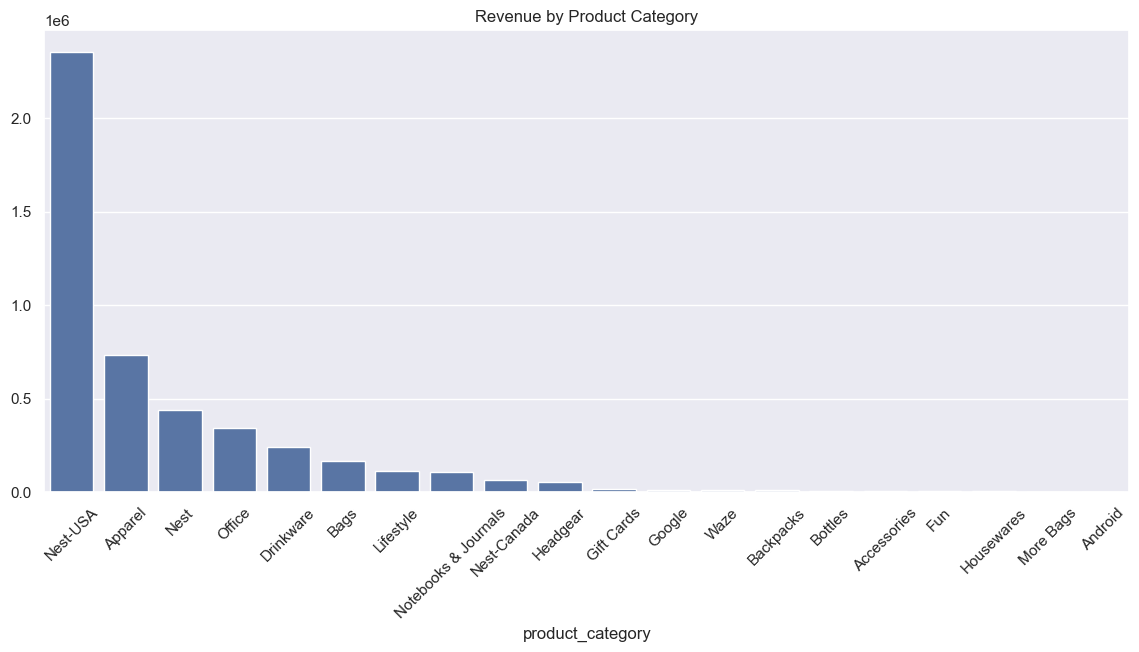

In [47]:
plt.figure(figsize=(14,6))
sns.barplot(x = cat_rev.index,y = cat_rev.values)
plt.title("Revenue by Product Category")
plt.xticks(rotation=45)
plt.show()

## Revenue by Location

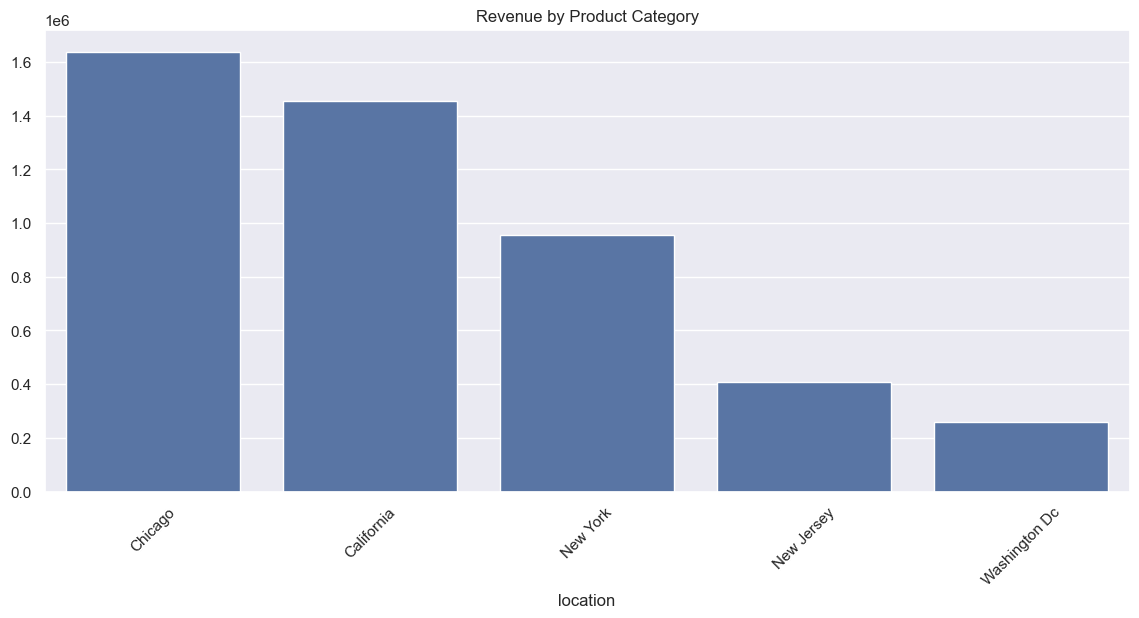

In [48]:
loc_rev = dfs.groupby('location')['invoice_value'].sum().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x = loc_rev.index,y = loc_rev.values)
plt.title("Revenue by Product Category")
plt.xticks(rotation=45)
plt.show()

## Day-of-Week Analysis (Orders & Revenue)

In [49]:
day_of_week = dfs.groupby('weekday').agg(
    orders = ('transaction_id','nunique'),
    revenue = ('invoice_value','sum')
).reset_index()

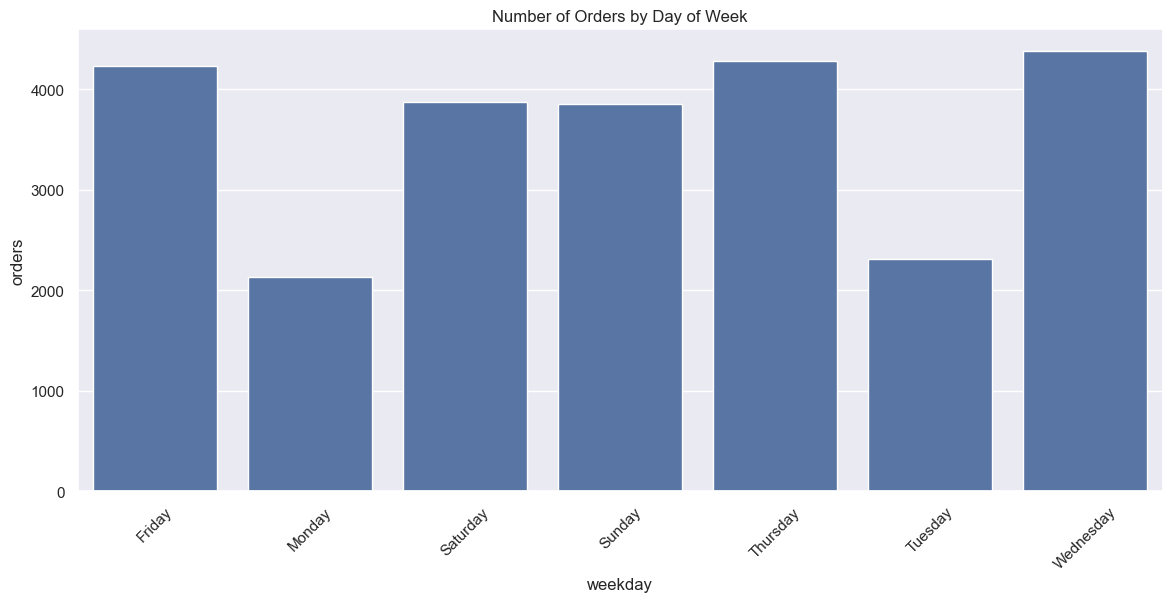

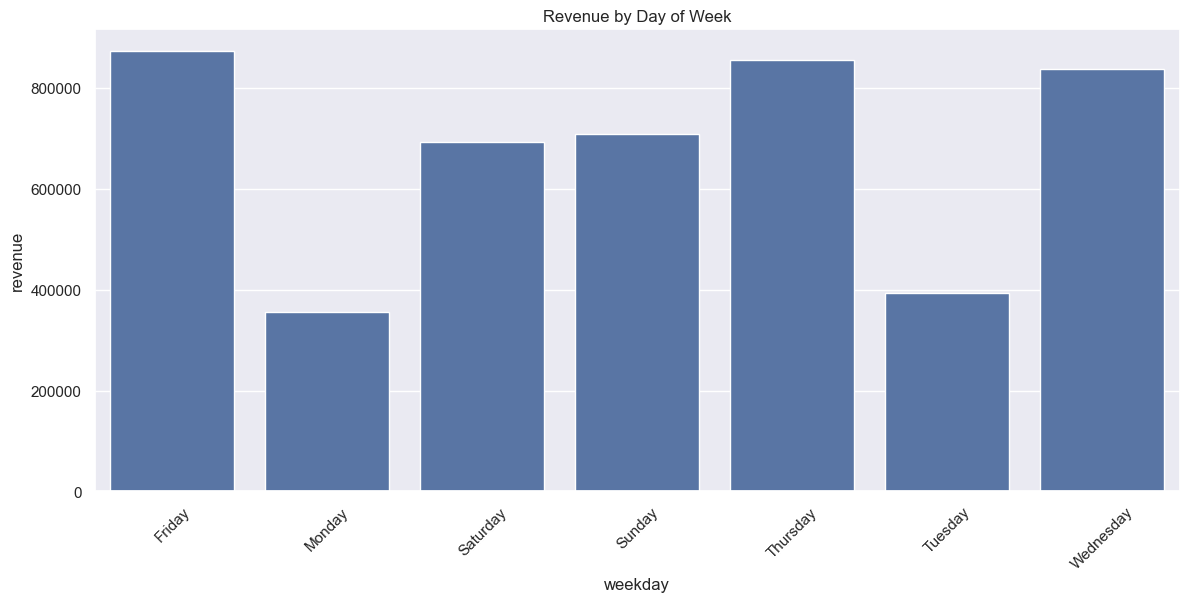

In [50]:
plt.figure(figsize=(14,6))
sns.barplot(data=day_of_week, x='weekday', y='orders')
plt.title("Number of Orders by Day of Week")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,6))
sns.barplot(data=day_of_week, x='weekday', y='revenue')
plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)
plt.show()

## Discount Impact on Revenue

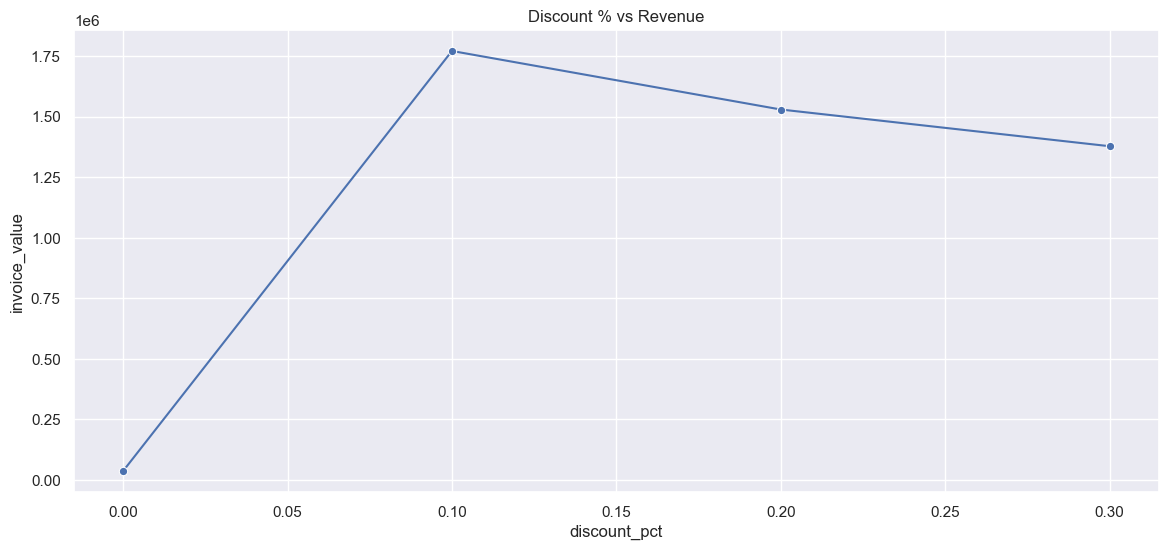

In [51]:
dist_impact = dfs.groupby('discount_pct')['invoice_value'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=dist_impact, x='discount_pct', y='invoice_value', marker='o')
plt.title("Discount % vs Revenue")
plt.show()

## Marketing Spend vs Revenue

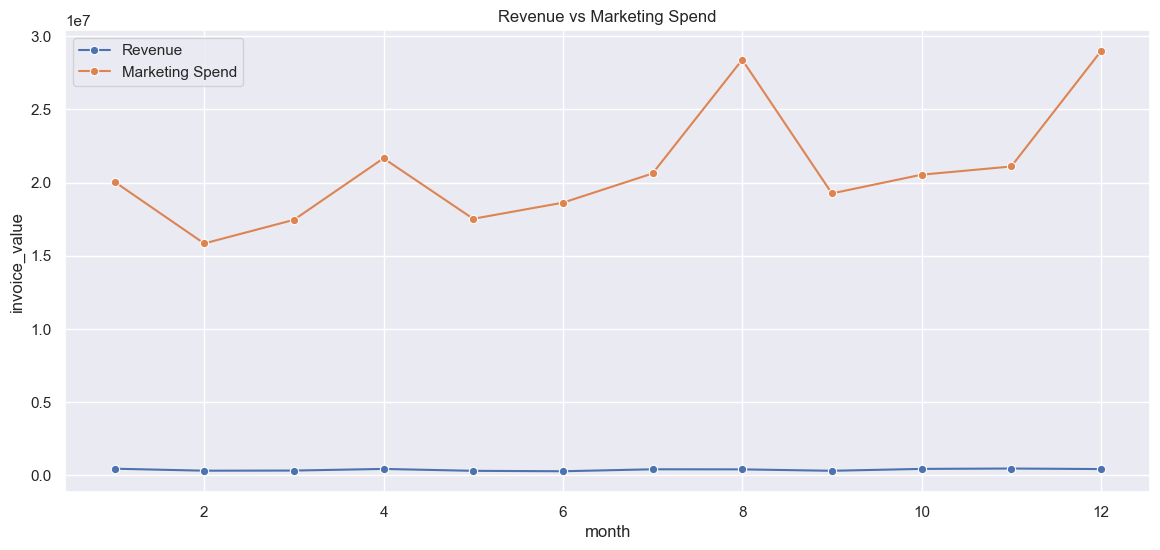

In [52]:
monthly_mkt = dfs.groupby(['year','month']).agg({
    'invoice_value':'sum',
    'online_spend':'sum',
    'offline_spend':'sum'
}).reset_index()

monthly_mkt['total_spend'] = monthly_mkt['online_spend'] + monthly_mkt['offline_spend']
monthly_mkt['mkt_pct_of_rev'] = monthly_mkt['total_spend'] / monthly_mkt['invoice_value']

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_mkt, x='month', y='invoice_value', marker='o', label='Revenue')
sns.lineplot(data=monthly_mkt, x='month', y='total_spend', marker='o', label='Marketing Spend')
plt.title("Revenue vs Marketing Spend")
plt.legend()
plt.show()

## Top 20 Best Selling Products (By Quantity)

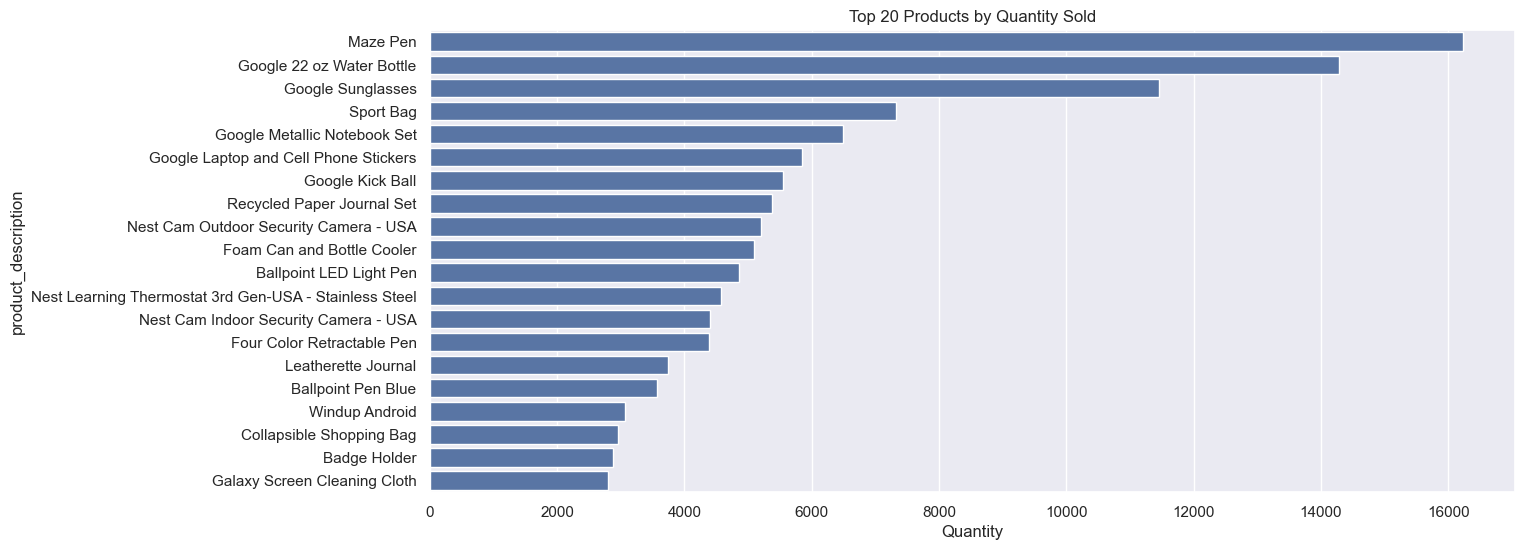

In [53]:
prod_qty = dfs.groupby('product_description')['quantity'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14,6))
sns.barplot(x=prod_qty.values, y=prod_qty.index)
plt.title("Top 20 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.show()

## Top 20 Products by Revenue

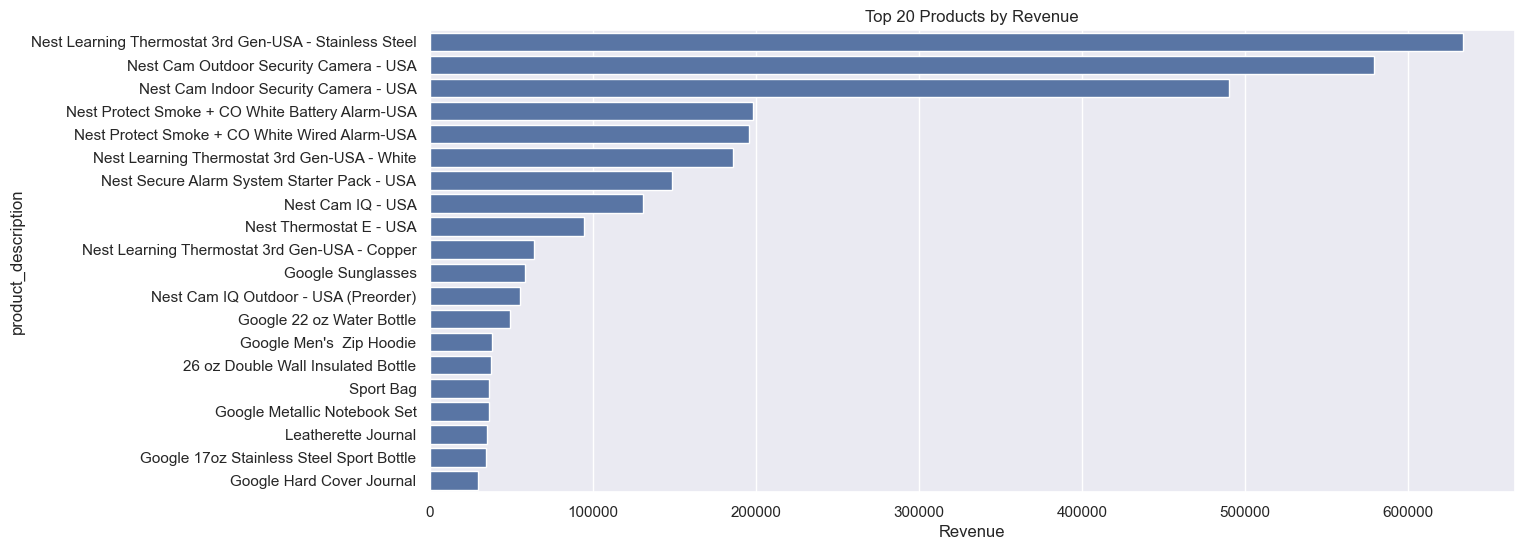

In [54]:
prod_rev = df.groupby('product_description')['invoice_value'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14,6))
sns.barplot(x=prod_rev.values, y=prod_rev.index)
plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue")
plt.show()

# --------------------------------------------------------------
# RFM + K-Means Segmentation Notebook
# --------------------------------------------------------------

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Data is Prepared for RFM

## Recency → Days since last purchase
## Frequency → Total transactions
## Monetary → Total Revenue

In [56]:
snapshot_date = dfs['transaction_date'].max() + pd.Timedelta(days=1)

rfm = dfs.groupby('customerid').agg({
    'transaction_date': lambda x: (snapshot_date - x.max()).days,
    'transaction_id': 'nunique',
    'invoice_value': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']
rfm.head()

,recency,frequency,monetary
customerid,,,
12346,108,1,174.98174
12347,60,31,12090.29580
12348,74,8,1501.92620
12350,18,11,1183.71394
12356,108,13,1753.45086


## Standardize RFM Data

In [58]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [60]:
rfm_scaled = pd.DataFrame(rfm_scaled,index=rfm.index,columns=rfm.columns)
rfm_scaled.head()

,recency,frequency,monetary
customerid,,,
12346,-0.365961,-0.686522,-0.589574
12347,-0.837001,0.515021,1.723901
12348,-0.699614,-0.406162,-0.331934
12350,-1.249160,-0.286007,-0.393718
12356,-0.365961,-0.205905,-0.283098


In [63]:
## Find Optimal K (Elbow Method)
sse = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init='auto')
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)
    

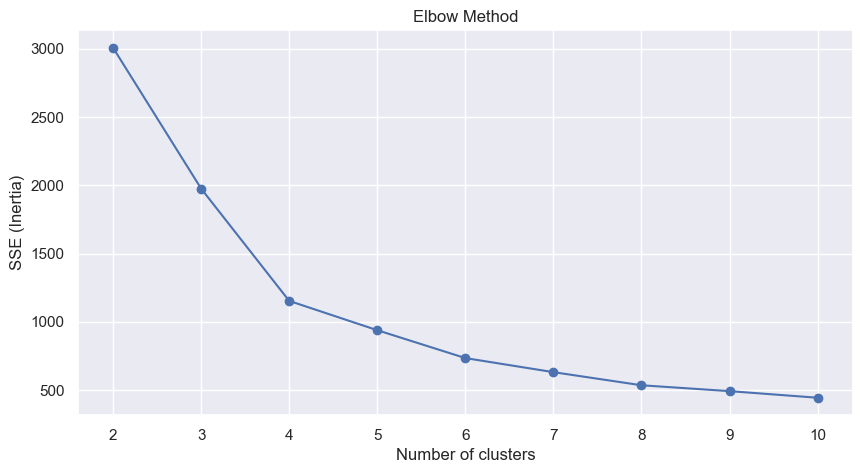

In [64]:

plt.figure(figsize=(10,5))
plt.plot(K, sse, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")
plt.show()

## Silhouette Score (Secondary Check)

In [65]:
for k in range(2,8):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init='auto')
    labels = kmeans.fit_predict(rfm_scaled)
    print(k,silhouette_score(rfm_scaled,labels))

2 0.5832699652991522
3 0.4266039539564066
4 0.44694257011548283
5 0.37994526204881884
6 0.39441917432255014
7 0.40373725109609926


## Create the final K model.

In [74]:
k_opt = 4
kmeans  = KMeans(n_clusters=k_opt,random_state=42,n_init='auto')
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

In [76]:
rfm.head()

,recency,frequency,monetary,cluster
customerid,,,,
12346,108,1,174.98174,0
12347,60,31,12090.29580,1
12348,74,8,1501.92620,0
12350,18,11,1183.71394,0
12356,108,13,1753.45086,0


## Analyze cluster profile

cluster_profile = rfm.groupby('cluster').agg({
    'recency':'mean',
    'frequency':'mean',
    'monetary':'mean',
    'recency':'count'
}).rename(columns = {'recency':'num_customers'})

In [78]:
cluster_profile

,num_customers,frequency,monetary
cluster,,,
0,744,12.856183,2121.786965
1,177,55.977401,10456.405881
2,541,10.229205,1726.665476
3,6,270.666667,58498.698917


## Visualize RFM Distributions by Cluster

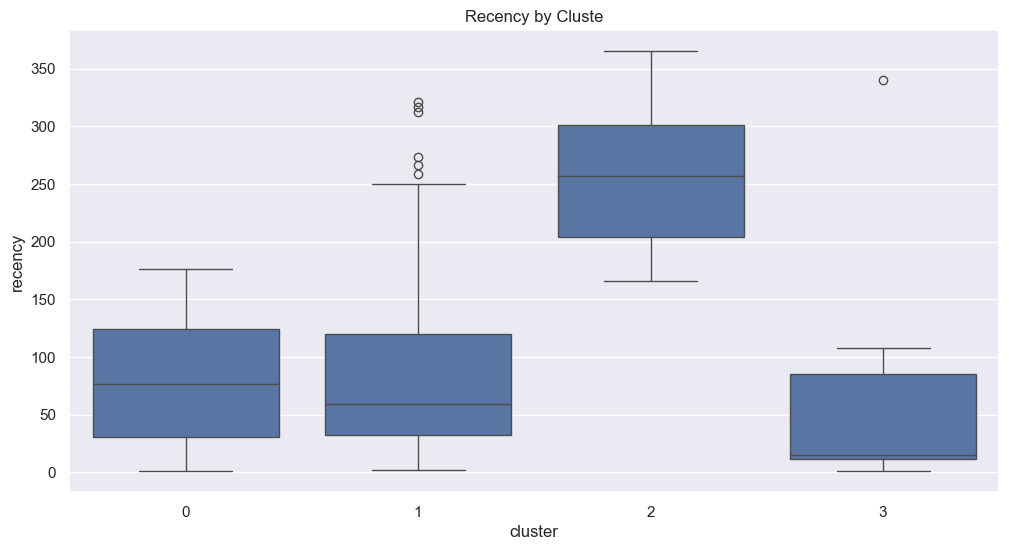

In [80]:
## Recency
plt.figure(figsize=(12,6))
sns.boxplot(data = rfm,x='cluster',y='recency')
plt.title('Recency by Cluste')
plt.show()

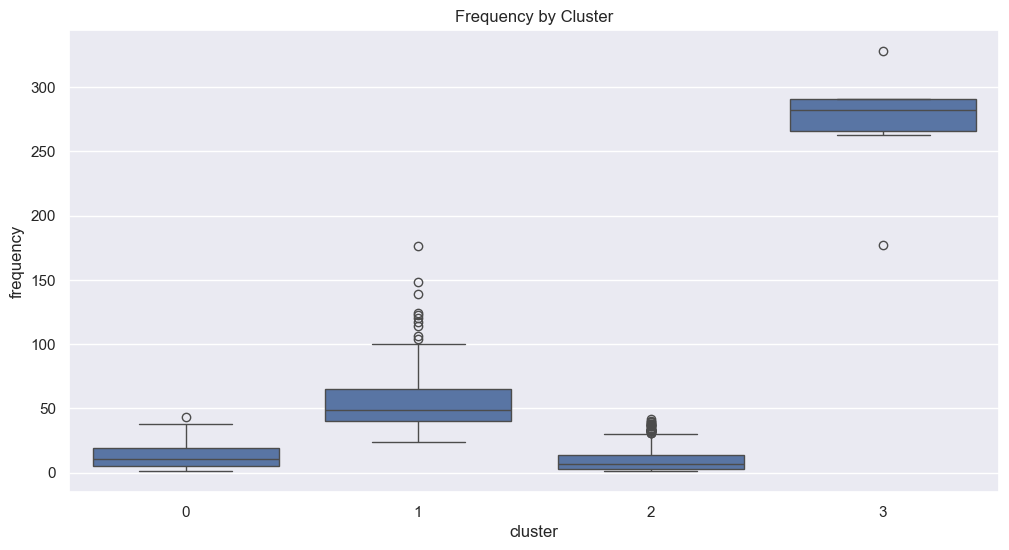

In [82]:
## Frequency
plt.figure(figsize=(12,6))
sns.boxplot(data=rfm, x='cluster', y='frequency')
plt.title("Frequency by Cluster")
plt.show()

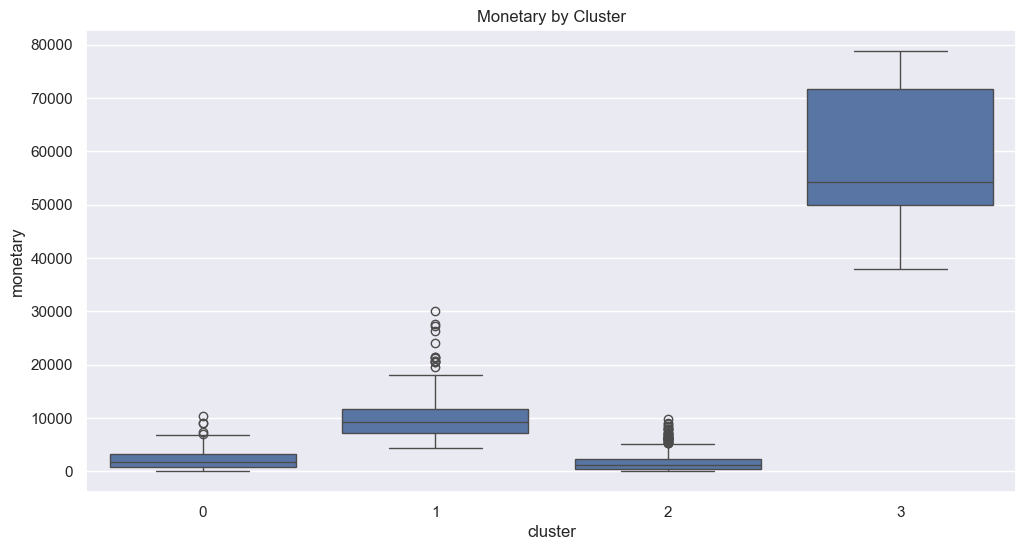

In [83]:
plt.figure(figsize=(12,6))
sns.boxplot(data=rfm, x='cluster', y='monetary')
plt.title("Monetary by Cluster")
plt.show()

In [84]:
cluster_map = rfm.groupby('cluster').median()
cluster_map

,recency,frequency,monetary
cluster,,,
0,77.0,10.5,1716.65722
1,59.0,49.0,9227.70631
2,257.0,7.0,1107.90844
3,15.5,282.5,54226.50857


In [86]:
## Based on map,assign segment labels
segment_labels = {
    0: "Premium",
    1: "Gold",
    2: "Silver",
    3: "Standard"
}

rfm['segment'] = rfm['cluster'].map(segment_labels)
rfm.head()

,recency,frequency,monetary,cluster,segment
customerid,,,,,
12346,108,1,174.98174,0,Premium
12347,60,31,12090.29580,1,Gold
12348,74,8,1501.92620,0,Premium
12350,18,11,1183.71394,0,Premium
12356,108,13,1753.45086,0,Premium


In [87]:
segment_summary = rfm.groupby('segment').agg({
    'recency':'mean',
    'frequency':'mean',
    'monetary':['mean','sum'],
    'cluster':'count'
}).rename(columns={'cluster':'num_customers'})

segment_summary

recency   frequency      monetary               num_customers
                mean        mean          mean           sum         count
segment                                                                   
Gold       82.553672   55.977401  10456.405881  1.850784e+06           177
Premium    79.782258   12.856183   2121.786965  1.578610e+06           744
Silver    256.613678   10.229205   1726.665476  9.341260e+05           541
Standard   81.833333  270.666667  58498.698917  3.509922e+05             6

# ============================================
# Predicting Customer Lifetime Value (Low Value/Medium Value/High Value
# ============================================

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [110]:
df = pd.read_csv("Cleaned_transaction_data.csv")
df.head()

,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295,4500,2424.5
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843,4500,2424.5
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230,4500,2424.5


## Aggregate Customer-Level Metrics

In [124]:
## # Total revenue per customer
customer_rev = df.groupby("customerid")["invoice_value"].sum().reset_index()
customer_rev.rename(columns={"invoice_Value":"total_revenue"}, inplace=True)


In [126]:
# Orders per customer
customer_freq = df.groupby("customerid")["transaction_id"].nunique().reset_index()
customer_freq.rename(columns={"transaction_id":"total_orders"}, inplace=True)


In [127]:
# Recency & tenure
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Recency snapshot date
snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)

# Recency & tenure
customer_recency = df.groupby("customerid").agg(
    Last_Purchase=('transaction_date','max'),
    First_Purchase=('transaction_date','min')
).reset_index()

In [128]:
customer_recency["Recency_Days"] = (snapshot_date - customer_recency["Last_Purchase"]).dt.days
customer_recency["Tenure_Days"] = (customer_recency["Last_Purchase"] - customer_recency["First_Purchase"]).dt.days + 1


In [129]:
# AOV
customer_aov = (df.groupby("customerid")["invoice_value"].sum() /
                df.groupby("customerid")["transaction_id"].nunique()).reset_index(name="AOV")


In [130]:

# Combine all features
customer_data = (
    customer_rev
    .merge(customer_freq, on="customerid")
    .merge(customer_recency[["customerid","Recency_Days","Tenure_Days"]], on="customerid")
    .merge(customer_aov, on="customerid")
)

customer_data.head()

,customerid,invoice_value,total_orders,Recency_Days,Tenure_Days,AOV
0,12346,174.98174,1,108,1,174.981740
1,12347,12090.29580,31,60,224,390.009542
2,12348,1501.92620,8,74,120,187.740775
3,12350,1183.71394,11,18,1,107.610358
4,12356,1753.45086,13,108,1,134.880835


## Create LTV Target (Low / Medium / High)

In [133]:
q1 = customer_data['invoice_value'].quantile(0.33)
q2 = customer_data['invoice_value'].quantile(0.70)

In [134]:
def assign_ltv(value):
    if value <= q1:
        return 'Low'
    elif value <= q2:
        return 'Medium'
    else:
        return 'High'

customer_data['LTV_class'] = customer_data['invoice_value'].apply(assign_ltv)
customer_data['LTV_class'].value_counts()

LTV_class
Medium    542
Low       485
High      441
Name: count, dtype: int64

## Feature Engineering + Scaling

In [137]:
features = customer_data.drop(columns=['customerid','LTV_class'])

In [138]:
target = customer_data['LTV_class']

In [139]:
scaler = StandardScaler()
scaled_feature = scaler.fit_transform(features)

In [140]:
X = pd.DataFrame(scaled_feature,columns=features.columns)
y = target

## Train/Test Split

In [142]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## Random Forest Model

In [145]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)      # ← MUST run this first!

y_pred = model.predict(X_test)   # ← Now it works

Classification Report
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       110
         Low       1.00      1.00      1.00       121
      Medium       1.00      1.00      1.00       136

    accuracy                           1.00       367
   macro avg       1.00      1.00      1.00       367
weighted avg       1.00      1.00      1.00       367


CONFUSION MATRIX:


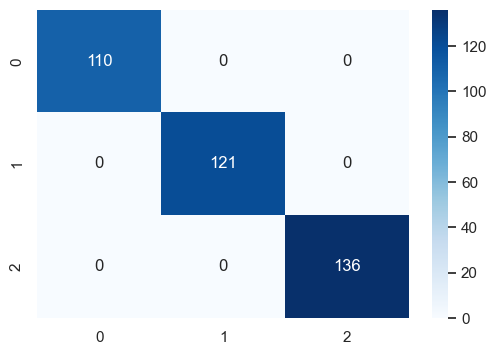

In [146]:
y_pred = model.predict(X_test)
print('Classification Report')
print(classification_report(y_test,y_pred))

print("\nCONFUSION MATRIX:")
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.show()

In [147]:
customer_data

,customerid,invoice_value,total_orders,Recency_Days,Tenure_Days,AOV,LTV_class
0,12346,174.98174,1,108,1,174.981740,Low
1,12347,12090.29580,31,60,224,390.009542,High
2,12348,1501.92620,8,74,120,187.740775,Medium
3,12350,1183.71394,11,18,1,107.610358,Medium
4,12356,1753.45086,13,108,1,134.880835,Medium
...,...,...,...,...,...,...,...
1463,18259,816.40980,3,271,1,272.136600,Low
1464,18260,2647.24033,19,88,106,139.328438,Medium
1465,18269,155.66092,2,195,77,77.830460,Low
1466,18277,301.02000,1,70,1,301.020000,Low


In [ ]:
## ++++++++++++++++++++++++++++==================================================================================================

In [148]:
df = pd.read_csv("Cleaned_transaction_data.csv")
df.head()

,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295,4500,2424.5
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843,4500,2424.5
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230,4500,2424.5


In [155]:
df['Transaction_Date'] = pd.to_datetime(df['transaction_date'])

## Customer-Level Aggregation

In [153]:
## Total_orders
orders = df.groupby('customerid')['transaction_date'].nunique().reset_index()
orders.rename(columns = {'transaction_id':'total_orders'},inplace = True)

In [157]:
## Regency and Tenure
## Recency and Tenure

# 1. Convert to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# 2. Snapshot date
snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)

# 3. Compute recency & tenure
cust_dates = df.groupby("customerid").agg(
    Last_Purchase=('transaction_date','max'),
    First_Purchase=('transaction_date','min')
).reset_index()

cust_dates["Recency_Days"] = (snapshot_date - cust_dates["Last_Purchase"]).dt.days
cust_dates["Tenure_Days"]  = (cust_dates["Last_Purchase"] - cust_dates["First_Purchase"]).dt.days

In [158]:
## Category Diversity (How many types customer bought)
cat_div = df.groupby('customerid')['product_category'].nunique().reset_index()
cat_div.rename(columns={'product_category':'category_diversity'}, inplace=True)

In [159]:
## Average Days Between Purchases (Customer Buying Frequency Pattern)
def avg_days_between(x):
    dates = x.sort_values()
    if len(dates) < 2:
        return np.nan
    return np.mean(np.diff(dates).astype('timedelta64[D]').astype(int))

avg_gap = df.groupby('customerid')['transaction_date'].apply(avg_days_between).reset_index()
avg_gap.rename(columns={'transaction_date':'avg_days_between_purchase'}, inplace=True)

# Fill customers with only one order
avg_gap['avg_days_between_purchase'].fillna(avg_gap['avg_days_between_purchase'].median(), inplace=True)

0        0.000000
1        3.779661
2        5.409091
3        0.000000
4        0.000000
          ...    
1463     0.000000
1464     2.692308
1465    10.857143
1466     0.018350
1467     0.722772
Name: avg_days_between_purchase, Length: 1468, dtype: float64

In [160]:
## Discounts Used Count (Behavioral, not revenue)
df["coupon_used"] = np.where(df["coupon_status"]=="Applied", 1, 0)

disc = df.groupby("customerid")["coupon_used"].sum().reset_index()
disc.rename(columns={"coupon_used":"discounts_used_count"}, inplace=True)

## Merge All

In [161]:
customer_features = (
    orders
    .merge(cust_dates[["customerid","Recency_Days","Tenure_Days"]], on="customerid")
    .merge(cat_div, on="customerid")
    .merge(avg_gap, on="customerid")
    .merge(disc, on="customerid")
)

customer_features.head()

,customerid,transaction_date,Recency_Days,Tenure_Days,category_diversity,avg_days_between_purchase,discounts_used_count
0,12346,1,108,0,2,0.000000,0
1,12347,3,60,223,10,3.779661,0
2,12348,2,74,119,6,5.409091,0
3,12350,1,18,0,4,0.000000,0
4,12356,1,108,0,7,0.000000,0


## Create LTV Target (Low / Medium / High)

In [162]:
rev = df.groupby("customerid")["invoice_value"].sum().reset_index()
rev.rename(columns={"invoice_value":"total_revenue"}, inplace=True)

# merge for target creation
customer_data = customer_features.merge(rev, on="customerid")

In [164]:
## Define LTV Classes
q1 = customer_data["total_revenue"].quantile(0.25)
q2 = customer_data["total_revenue"].quantile(0.75)

def ltv_bucket(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

customer_data["LTV_Class"] = customer_data["total_revenue"].apply(ltv_bucket)

## Prepare Final Modeling

In [167]:
X = customer_data.drop(columns=["customerid","total_revenue","LTV_Class"])
y = customer_data["LTV_Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train/Test Split

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

## Train Random Forest Model

In [169]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluate Model

Classification Report:
              precision    recall  f1-score   support

        High       0.73      0.71      0.72        92
         Low       0.66      0.65      0.66        92
      Medium       0.69      0.70      0.70       183

    accuracy                           0.69       367
   macro avg       0.69      0.69      0.69       367
weighted avg       0.69      0.69      0.69       367


Confusion Matrix:


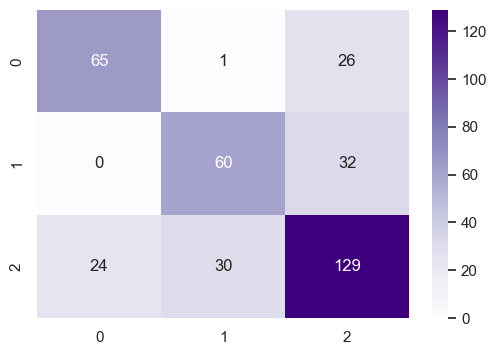

In [170]:
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Purples")
plt.show()

## Feature Importance

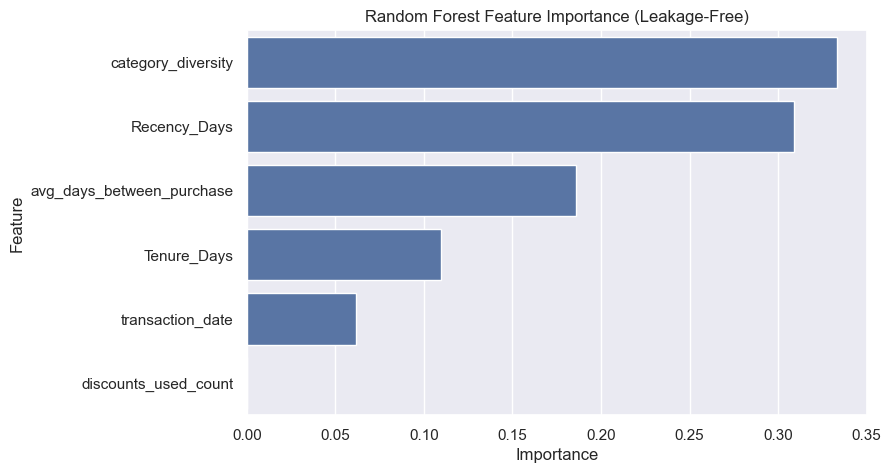

,Feature,Importance
3,category_diversity,0.333466
1,Recency_Days,0.309006
4,avg_days_between_purchase,0.185791
2,Tenure_Days,0.109855
0,transaction_date,0.061882
5,discounts_used_count,0.000000


In [171]:
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=fi, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance (Leakage-Free)")
plt.show()

fi

## Save Final Predictions

In [172]:
customer_data["LTV_Predicted"] = model.predict(X_scaled)
customer_data.to_csv("Customer_LTV_LeakageFree_Predictions.csv", index=False)

customer_data.head()

,customerid,transaction_date,Recency_Days,Tenure_Days,category_diversity,avg_days_between_purchase,discounts_used_count,total_revenue,LTV_Class,LTV_Predicted
0,12346,1,108,0,2,0.000000,0,174.98174,Low,Medium
1,12347,3,60,223,10,3.779661,0,12090.29580,High,High
2,12348,2,74,119,6,5.409091,0,1501.92620,Medium,Medium
3,12350,1,18,0,4,0.000000,0,1183.71394,Medium,Medium
4,12356,1,108,0,7,0.000000,0,1753.45086,Medium,Medium


The comparison clearly shows:

The initial 100% accuracy was misleading due to data leakage.

The post-correction accuracy of 69% represents a realistic and trustworthy measure of model capability.

The updated results also highlight areas for improvement, such as feature engineering, handling class imbalance, and tuning the model.

# ============================================================
# MARKET BASKET ANALYSIS (CROSS-SELLING) NOTEBOOK

In [173]:
df = pd.read_csv("Cleaned_transaction_data.csv")
df.head()


,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295,4500,2424.5
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843,4500,2424.5
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230,4500,2424.5


In [174]:
## Basic EDA
print(df.shape)
df.info()
df.describe(include='all')

(52924, 26)
<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerid           52924 non-null  int64  
 1   gender               52924 non-null  str    
 2   location             52924 non-null  str    
 3   tenure_months        52924 non-null  int64  
 4   transaction_id       52924 non-null  int64  
 5   transaction_date     52924 non-null  str    
 6   product_sku          52924 non-null  str    
 7   product_description  52924 non-null  str    
 8   product_category     52924 non-null  str    
 9   quantity             52924 non-null  int64  
 10  avg_price            52924 non-null  float64
 11  delivery_charges     52924 non-null  float64
 12  coupon_status        52924 non-null  str    
 13  year                 52924 non-null  int64  
 14  month                52924 non-null  int64  
 15  day                  52924 non-null

,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
count,52924.00000,52924,52924,52924.000000,52924.000000,52924,52924,52924,52924,52924.000000,...,52924.000000,52924,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000
unique,NaN,2,5,NaN,NaN,365,1145,404,20,NaN,...,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,F,Chicago,NaN,NaN,2019-11-27,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Apparel,NaN,...,NaN,Friday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,33007,18380,NaN,NaN,335,3511,3511,18126,NaN,...,NaN,9266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,15346.70981,NaN,NaN,26.127995,32409.825675,NaN,NaN,NaN,NaN,4.497638,...,27.078679,NaN,0.198024,0.137462,88.254754,70.758756,78.563156,89.080787,2830.914141,1893.109119
std,1766.55602,NaN,NaN,13.478285,8648.668977,NaN,NaN,NaN,NaN,20.104711,...,14.536834,NaN,0.082789,0.045825,163.993178,136.418512,149.875728,152.506512,936.154247,807.014092
min,12346.00000,NaN,NaN,2.000000,16679.000000,NaN,NaN,NaN,NaN,1.000000,...,1.000000,NaN,0.000000,0.050000,0.400000,0.287000,0.315700,4.375440,500.000000,320.250000
25%,13869.00000,NaN,NaN,15.000000,25384.000000,NaN,NaN,NaN,NaN,1.000000,...,15.000000,NaN,0.100000,0.100000,11.960000,9.513000,11.225340,18.545760,2500.000000,1252.630000
50%,15311.00000,NaN,NaN,27.000000,32625.500000,NaN,NaN,NaN,NaN,1.000000,...,28.000000,NaN,0.200000,0.180000,30.390000,24.500000,28.865160,40.683740,3000.000000,1837.870000
75%,16996.25000,NaN,NaN,37.000000,39126.250000,NaN,NaN,NaN,NaN,2.000000,...,39.000000,NaN,0.300000,0.180000,121.300000,104.300000,114.730000,123.447600,3500.000000,2425.350000


## Clean Data for Market Basket Analysis

In [178]:
mb_df = df.copy()

# Ensure description cleaned
mb_df['product_description'] = mb_df['product_description'].str.strip().str.lower()

# Remove returns and invalid quantities
mb_df = mb_df[mb_df['quantity'] > 0]

# Remove missing descriptions
mb_df = mb_df.dropna(subset=['product_description'])

mb_df.head()

,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,nest learning thermostat 3rd gen-usa - stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,nest learning thermostat 3rd gen-usa - stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,google laptop and cell phone stickers,Office,1,...,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295,4500,2424.5
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,google men's 100% cotton short sleeve hero tee...,Apparel,5,...,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843,4500,2424.5
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,google canvas tote natural/navy,Bags,1,...,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230,4500,2424.5


## Build Basket Matrix

In [181]:
basket = (
    mb_df.groupby(['transaction_id','product_category'])['quantity']
         .sum()
         .unstack()
         .fillna(0)
)

# Convert counts to 1/0 boolean matrix
basket = (basket > 0).astype(int)
basket.head()

product_category,Accessories,Android,Apparel,Backpacks,Bags,Bottles,Drinkware,Fun,Gift Cards,Google,Headgear,Housewares,Lifestyle,More Bags,Nest,Nest-Canada,Nest-USA,Notebooks & Journals,Office,Waze
transaction_id,,,,,,,,,,,,,,,,,,,,
16679,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
16680,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
16681,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
16682,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
16684,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


## Frequent Itemsets (Apriori)

In [186]:
from mlxtend.frequent_patterns import apriori, association_rules

In [187]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,   # 2% minimum support
    use_colnames=True
)

frequent_itemsets.sort_values('support', ascending=False).head(10)

C:\Users\vivek\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
6,0.463908,frozenset({Nest-USA})
0,0.324369,frozenset({Apparel})
8,0.140697,frozenset({Office})
2,0.100714,frozenset({Drinkware})
5,0.078768,frozenset({Nest})
4,0.068313,frozenset({Lifestyle})
12,0.062128,"frozenset({Apparel, Office})"
1,0.061650,frozenset({Bags})
16,0.046287,"frozenset({Drinkware, Office})"
10,0.045010,"frozenset({Drinkware, Apparel})"


## Association Rules (Lift-Based)

In [188]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules = rules.sort_values("lift", ascending=False)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13,frozenset({Lifestyle}),frozenset({Drinkware}),0.068313,0.100714,0.025857,0.378505,3.758203,1.0,0.018977,1.446971,0.787728,0.180602,0.308901,0.317620
12,frozenset({Drinkware}),frozenset({Lifestyle}),0.100714,0.068313,0.025857,0.256735,3.758203,1.0,0.018977,1.253506,0.816109,0.180602,0.202238,0.317620
17,frozenset({Office}),frozenset({Lifestyle}),0.140697,0.068313,0.035114,0.249575,3.653381,1.0,0.025503,1.241545,0.845197,0.201927,0.194552,0.381797
16,frozenset({Lifestyle}),frozenset({Office}),0.068313,0.140697,0.035114,0.514019,3.653381,1.0,0.025503,1.768182,0.779533,0.201927,0.434447,0.381797
9,frozenset({Bags}),frozenset({Drinkware}),0.061650,0.100714,0.021707,0.352104,3.496065,1.0,0.015498,1.388008,0.760872,0.154326,0.279543,0.283817


## Clean Up Rules 

In [189]:
rules_clean = rules.copy()

rules_clean['antecedents'] = rules_clean['antecedents'].apply(lambda x: ", ".join(list(x)))
rules_clean['consequents'] = rules_clean['consequents'].apply(lambda x: ", ".join(list(x)))

rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

,antecedents,consequents,support,confidence,lift
13,Lifestyle,Drinkware,0.025857,0.378505,3.758203
12,Drinkware,Lifestyle,0.025857,0.256735,3.758203
17,Office,Lifestyle,0.035114,0.249575,3.653381
16,Lifestyle,Office,0.035114,0.514019,3.653381
9,Bags,Drinkware,0.021707,0.352104,3.496065
8,Drinkware,Bags,0.021707,0.215531,3.496065
22,Drinkware,"Apparel, Office",0.020670,0.205230,3.303317
19,"Apparel, Office",Drinkware,0.020670,0.332691,3.303317
15,Office,Drinkware,0.046287,0.328985,3.266516
14,Drinkware,Office,0.046287,0.459588,3.266516


## Plot Top Cross-Selling Rules (By Lift)

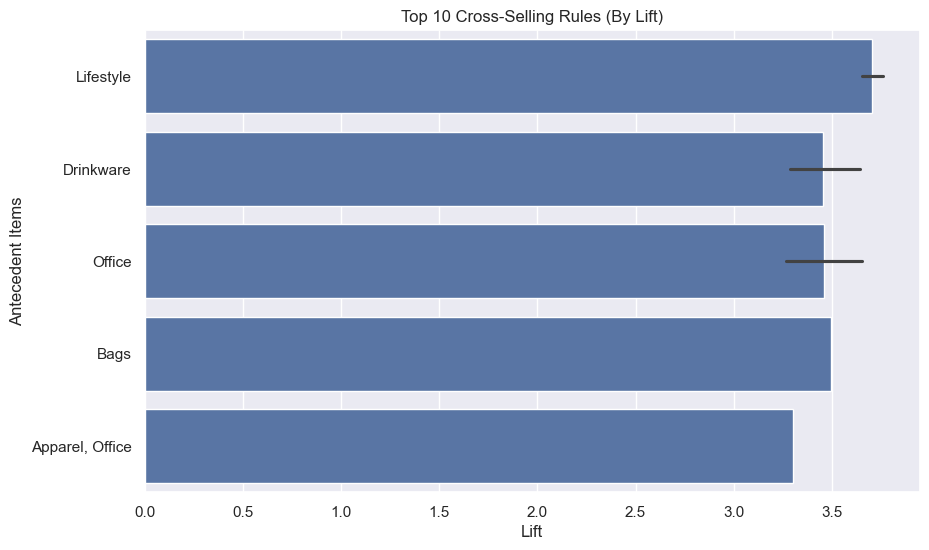

In [191]:
top_rules = rules_clean.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_rules,
    x="lift",
    y="antecedents"
)
plt.title("Top 10 Cross-Selling Rules (By Lift)")
plt.xlabel("Lift")
plt.ylabel("Antecedent Items")
plt.show()

## Products Sold Together With a Target Item

In [192]:
target_item = "paper"  # change to any item name

rules_for_item = rules_clean[
    rules_clean['antecedents'].str.contains(target_item) |
    rules_clean['consequents'].str.contains(target_item)
]

rules_for_item.sort_values("lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [193]:
rules_clean['antecedents'] = rules_clean['antecedents'].apply(lambda x: ','.join(list(x)))
rules_clean['consequents'] = rules_clean['consequents'].apply(lambda x: ','.join(list(x)))

In [194]:
target_item = "paper".lower()

rules_for_item = rules_clean[
    rules_clean['antecedents'].str.lower().str.contains(target_item) |
    rules_clean['consequents'].str.lower().str.contains(target_item)
]

rules_for_item.sort_values("lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


# ============================================================
# NEXT PURCHASE DAY PREDICTION NOTEBOOK (0-30, 30-60, 60-90, 90+)
# ============================================================


In [222]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

In [223]:
df = pd.read_csv("Cleaned_transaction_data.csv")
df.head()


,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295,4500,2424.5
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843,4500,2424.5
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230,4500,2424.5


In [224]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df = df.sort_values(['customerid', 'transaction_date'])

In [225]:
## Compute “days to next purchase”
df['next_purchase_date'] = df.groupby('customerid')['transaction_date'].shift(-1)
df['days_to_next_purchase'] = (
    df['next_purchase_date'] - df['transaction_date']
).dt.days

## Remove customers with only one purchase

In [226]:
repeat_df = df.dropna(subset=['days_to_next_purchase'])

Create New Bucket Categories
✔️ 0–30
✔️ 31–90
✔️ 90+

In [227]:
def bucketize(x):
    if x <= 30:
        return "0-30"
    elif x <= 90:
        return "31-90"
    else:
        return "90+"

repeat_df['purchase_bucket'] = repeat_df['days_to_next_purchase'].apply(bucketize)

In [228]:
repeat_df['purchase_bucket'].value_counts()

purchase_bucket
0-30     50577
31-90      479
90+        400
Name: count, dtype: int64

## Build Customer-Level Feature Matrix

In [229]:
features = repeat_df.groupby('customerid').agg({
    'days_to_next_purchase': 'mean',
    'quantity': 'sum',
    'invoice_value': 'sum',
    'product_sku': 'nunique',
    'month': 'nunique',
    'weekday': 'nunique',
    'offline_spend': 'sum',
    'online_spend': 'sum',
    'discount_pct': 'mean',
    'tenure_months': 'max',
    'purchase_bucket': 'first'
}).reset_index()

## Train/Test Split

In [230]:
X = features.drop(['customerid', 'purchase_bucket'], axis=1)
y = features['purchase_bucket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

## Scaling

In [231]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Fix Imbalance with SMOTE

In [232]:
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print(y_train_bal.value_counts())

purchase_bucket
0-30     1025
90+      1025
31-90    1025
Name: count, dtype: int64


In [233]:
brf = BalancedRandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42
)

brf.fit(X_train_bal, y_train_bal)

,n_estimators,500
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [234]:
brf = BalancedRandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42
)

brf.fit(X_train_bal, y_train_bal)

,n_estimators,500
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [235]:
y_pred = brf.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        0-30       0.98      0.99      0.99       342
       31-90       0.20      0.25      0.22         4
         90+       0.00      0.00      0.00         5

    accuracy                           0.97       351
   macro avg       0.39      0.41      0.40       351
weighted avg       0.96      0.97      0.96       351

[[338   2   2]
 [  3   1   0]
 [  3   2   0]]


In [240]:
## Feature Importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': brf.feature_importances_
}).sort_values('importance', ascending=False)

importances

,feature,importance
0,days_to_next_purchase,0.295719
6,offline_spend,0.181450
4,month,0.100425
1,quantity,0.081369
3,product_sku,0.071269
8,discount_pct,0.070334
7,online_spend,0.063580
5,weekday,0.058346
9,tenure_months,0.046175
2,invoice_value,0.031334


In [241]:
## Predict for All Customers
features['predicted_bucket'] = brf.predict(scaler.transform(X))

features[['customerid', 'predicted_bucket']].head()

,customerid,predicted_bucket
0,12346,0-30
1,12347,0-30
2,12348,0-30
3,12350,0-30
4,12356,0-30


## ==============================================================
==========Perform cohort analysis by defining below cohorts 
 Customers who started in each month and understand their behaviour  
 Which Month cohort has maximum retention? =======================

In [243]:
df = pd.read_csv("Cleaned_transaction_data.csv")
df.head()

,customerid,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,week,weekday,discount_pct,gst,base_amount,after_discount,after_tax,invoice_value,offline_spend,online_spend
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,1,Tuesday,0.1,0.10,153.71,138.339,152.1729,158.6729,4500,2424.5
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,1,Tuesday,0.1,0.10,2.05,1.845,2.0295,8.5295,4500,2424.5
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,1,Tuesday,0.1,0.18,87.65,78.885,93.0843,99.5843,4500,2424.5
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,1,Tuesday,0.1,0.18,16.50,14.850,17.5230,24.0230,4500,2424.5


In [244]:
df.columns

Index(['customerid', 'gender', 'location', 'tenure_months', 'transaction_id',
       'transaction_date', 'product_sku', 'product_description',
       'product_category', 'quantity', 'avg_price', 'delivery_charges',
       'coupon_status', 'year', 'month', 'day', 'week', 'weekday',
       'discount_pct', 'gst', 'base_amount', 'after_discount', 'after_tax',
       'invoice_value', 'offline_spend', 'online_spend'],
      dtype='str')

In [245]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['customerid'] = df['customerid'].astype(str)

## Cohort Month (First Month Customer Appeared)

In [246]:
# customer first purchase month
df['cohort_month'] = df.groupby('customerid')['transaction_date'] \
                        .transform('min') \
                        .dt.to_period('M')


## Create Transaction Month

In [247]:
df['order_month'] = df['transaction_date'].dt.to_period('M')

## Calculate Cohort Index (Months since first purchase)

def get_cohort_index(row):
    return ((row['order_month'].year - row['cohort_month'].year) * 12 +
            (row['order_month'].month - row['cohort_month'].month) + 1)

df['cohort_index'] = df.apply(get_cohort_index, axis=1)


## Build Cohort Table (Unique Customers)

In [249]:
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customerid'] \
                .nunique() \
                .reset_index()

cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customerid'
)


## Retention Matrix

In [250]:
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3)

## Visualize Retention Heatmap

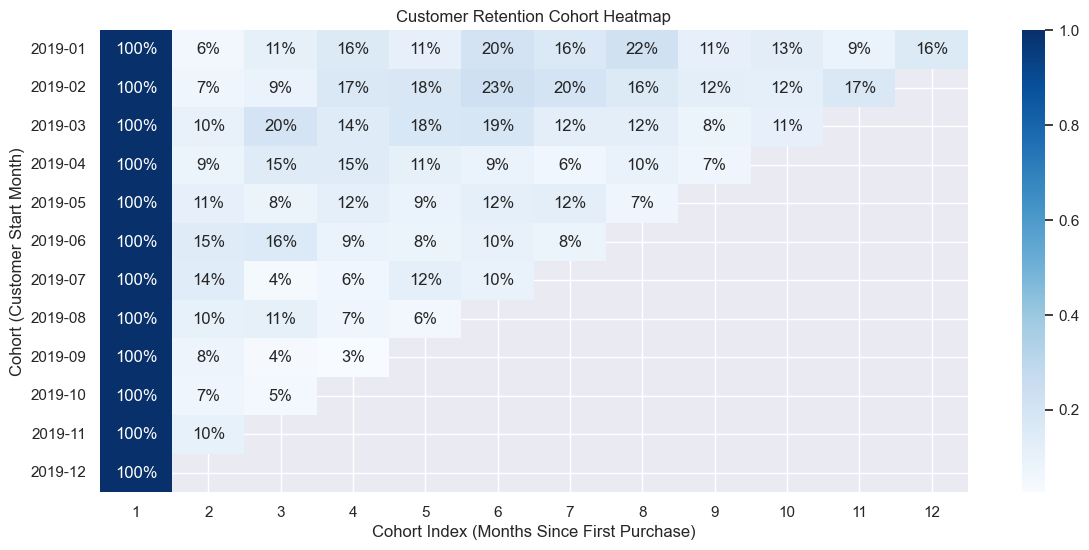

In [251]:
plt.figure(figsize=(14, 6))
sns.heatmap(retention_matrix, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention Cohort Heatmap")
plt.ylabel("Cohort (Customer Start Month)")
plt.xlabel("Cohort Index (Months Since First Purchase)")
plt.show()

## Cohort Has Maximum Retention

In [252]:
retention_matrix['avg_retention'] = retention_matrix.mean(axis=1)

best_cohort = retention_matrix['avg_retention'].idxmax()
best_value = retention_matrix['avg_retention'].max()

In [253]:
## Output the Best Cohort
print("Cohort month with maximum retention:", best_cohort)
print("Average retention:", round(best_value*100, 2), "%")

Cohort month with maximum retention: 2019-12
Average retention: 100.0 %


In [254]:
valid_cohorts = retention_matrix[retention_matrix.count(axis=1) >= 3]
best_cohort = valid_cohorts['avg_retention'].idxmax()
best_value = valid_cohorts['avg_retention'].max()

print("Best cohort (min 3 months data):", best_cohort)
print("Avg retention:", round(best_value * 100, 2), "%")

Best cohort (min 3 months data): 2019-11
Avg retention: 55.15 %


In [255]:
second_month_retention = retention_matrix[2].dropna()

best_cohort = second_month_retention.idxmax()
best_value = second_month_retention.max()

print("Best cohort (2nd month retention):", best_cohort)
print("2nd month retention:", round(best_value*100, 2), "%")

Best cohort (2nd month retention): 2019-06
2nd month retention: 14.6 %


## =====================================  THANKS  =======================================================================